In [1]:
import os
import torch
from transformers import ViTImageProcessor, ViTConfig, ViTForImageClassification
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

In [2]:
# Define paths
base_dir = '/kaggle/input/aptos2019-blindness-detection'
train_dir = "/kaggle/input/aptos2019-blindness-detection/train_images"
val_dir = "/kaggle/input/aptos2019-blindness-detection/test_images"
csv_file = os.path.join(base_dir, 'train.csv')

In [3]:
# Load dataset
df = pd.read_csv(csv_file)

# Extract features (X) and labels (y)
X = df.iloc[:, 0].values.reshape(-1, 1)  # Image filenames
y = df.iloc[:, 1].values  # Labels

# Apply Random Oversampling to balance classes
oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Create new balanced dataframe
df_balanced = pd.DataFrame({
    'id_code': X_resampled.flatten(),
    'diagnosis': y_resampled
})

# Save balanced dataset for training
# Save balanced dataset for training in a writable directory
df_balanced.to_csv("/kaggle/working/train_balanced_version.csv", index=False)
# Print class distribution
print("Original class distribution:", Counter(y))
print("Balanced class distribution:", Counter(y_resampled))

Original class distribution: Counter({0: 1805, 2: 999, 1: 370, 4: 295, 3: 193})
Balanced class distribution: Counter({2: 1805, 4: 1805, 1: 1805, 0: 1805, 3: 1805})


In [4]:
# Load the pre-trained processor
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

# Load the configuration and modify it for 5 classes
config = ViTConfig.from_pretrained('google/vit-base-patch16-224')
config.num_labels = 5  # Set the number of classes to 5
config.id2label = {
    0: "No DR",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR"
}
config.label2id = {v: k for k, v in config.id2label.items()}

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

In [5]:
# Load the model
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    config=config,
    ignore_mismatched_sizes=True
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# Define transforms for training
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
])


In [7]:
# Dataset class
class APTOSDataset(Dataset):
    def __init__(self, csv_file, img_dir, processor, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.data.iloc[idx, 0] + '.png')
        image = Image.open(img_name).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        inputs = self.processor(images=image, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        
        label = torch.tensor(self.data.iloc[idx, 1], dtype=torch.long)
        return {'pixel_values': inputs['pixel_values'], 'labels': label}

# Load balanced dataset
balanced_csv_file = "/kaggle/working/train_balanced_version.csv"
full_dataset = APTOSDataset(balanced_csv_file, train_dir, processor, transform=None)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Apply transforms
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = None


In [8]:
# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)

In [9]:
from transformers import AdamW

# Define optimizer
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

# Define loss function
criterion = torch.nn.CrossEntropyLoss()

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [10]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()
        
        inputs = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

# Validation loop
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating"):
            inputs = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(inputs).logits
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

In [11]:
import time

num_epochs = 10  # Adjust as needed

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    start_time = time.time()  # Start time
    
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    end_time = time.time()  # End time
    epoch_time = end_time - start_time  # Compute time taken

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Epoch {epoch+1} Time: {epoch_time:.2f} seconds\n")

Epoch 1/10


Validating: 100%|██████████| 113/113 [02:19<00:00,  1.23s/it]


Train Loss: 0.5510 | Train Acc: 78.88%
Val Loss: 0.3028 | Val Acc: 89.75%
Epoch 1 Time: 656.86 seconds

Epoch 2/10


Validating: 100%|██████████| 113/113 [02:15<00:00,  1.20s/it]


Train Loss: 0.1622 | Train Acc: 94.79%
Val Loss: 0.1592 | Val Acc: 95.29%
Epoch 2 Time: 707.15 seconds

Epoch 3/10


...

Train Loss: 0.0425 | Train Acc: 98.06%
Val Loss: 0.1113 | Val Acc: 96.18%
Epoch 8 Time: 713.50 seconds

Epoch 9/10


Validating: 100%|██████████| 113/113 [02:16<00:00,  1.21s/it]


Train Loss: 0.0450 | Train Acc: 98.01%
Val Loss: 0.1481 | Val Acc: 95.84%
Epoch 9 Time: 721.29 seconds

Epoch 10/10


Validating: 100%|██████████| 113/113 [02:16<00:00,  1.20s/it]

Train Loss: 0.0622 | Train Acc: 97.35%
Val Loss: 0.1336 | Val Acc: 95.29%
Epoch 10 Time: 729.25 seconds



In [12]:
torch.save(model.state_dict(), "/kaggle/working/vit_dr_classification.pth")

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [14]:
def get_predictions_and_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            inputs = batch['pixel_values'].to(device)
            labels = batch['labels'].cpu().numpy()  # Convert to numpy
            
            outputs = model(inputs).logits
            preds = torch.argmax(outputs, dim=1).cpu().numpy()  # Get predicted class
            
            all_preds.extend(preds)
            all_labels.extend(labels)

    return np.array(all_preds), np.array(all_labels)

In [15]:
def plot_confusion_matrix(model, dataloader, device, class_names):
    preds, labels = get_predictions_and_labels(model, dataloader, device)
    
    # Compute confusion matrix
    cm = confusion_matrix(labels, preds)
    
    # Plot using seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

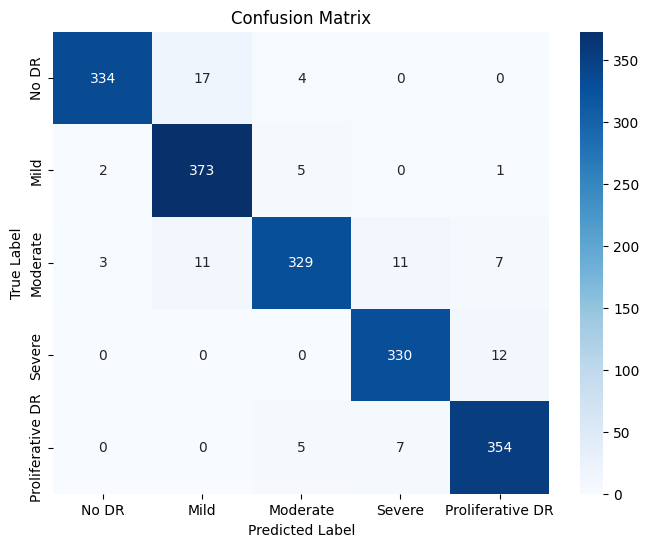

In [16]:
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]  # Update if needed
plot_confusion_matrix(model, val_loader, device, class_names)